# Phase 5 - Evaluation

Evaluating the models on the test split

In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score, precision_score, recall_score

## Test Data Preparation and Model Loading

In [2]:
test_df = pd.read_csv("../data/processed/test_data.csv")
for frame in (test_df,):
    frame["cleaned_text"] = frame["cleaned_text"].fillna("").astype(str)

with open("../models/tfidf_vectorizer.pkl", "rb") as file_handle:
    vectorizer = pickle.load(file_handle)

X_test = vectorizer.transform(test_df["cleaned_text"])
y_test = test_df["class"]

model_names = [
    "logistic_regression",
    "naive_bayes",
    "linear_svm",
    "calibrated_svm",
    "voting_classifier",
]

models = {}
for model_name in model_names:
    with open(f"../models/{model_name}.pkl", "rb") as file_handle:
        models[model_name] = pickle.load(file_handle)

results = []
results_dir = Path("../results")
figures_dir = results_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

label_order = ["non-suicide", "suicide"]


## Final Evaluation of All Models on the Test Set

In [3]:
for model_name, model in models.items():
    predictions = model.predict(X_test)
    results.append(
        {
            "model": model_name,
            "accuracy": accuracy_score(y_test, predictions),
            "precision": precision_score(y_test, predictions, pos_label="suicide"),
            "recall": recall_score(y_test, predictions, pos_label="suicide"),
            "f1": f1_score(y_test, predictions, pos_label="suicide"),
        }
    )

    report = classification_report(y_test, predictions)
    print(f"\n{model_name}\n{'-' * len(model_name)}")
    print(report)

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        labels=label_order,
        display_labels=label_order,
        cmap="Blues",
        ax=ax,
        colorbar=False,
    )
    ax.set_title(f"{model_name} confusion matrix")
    fig.tight_layout()
    fig_path = figures_dir / f"{model_name}_confusion_matrix.png"
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved figure: {fig_path}")

results_df = pd.DataFrame(results).sort_values(by="f1", ascending=False).reset_index(drop=True)
comparison_path = results_dir / "comparison_results.csv"
results_df.to_csv(comparison_path, index=False)

print("\nTest comparison results:")
print(results_df.to_string(index=False))
print("\nSaved comparison table:", comparison_path)


logistic_regression
-------------------
              precision    recall  f1-score   support

 non-suicide       0.93      0.95      0.94     11604
     suicide       0.95      0.93      0.94     11604

    accuracy                           0.94     23208
   macro avg       0.94      0.94      0.94     23208
weighted avg       0.94      0.94      0.94     23208

Saved figure: ../results/figures/logistic_regression_confusion_matrix.png

naive_bayes
-----------
              precision    recall  f1-score   support

 non-suicide       0.95      0.87      0.91     11604
     suicide       0.88      0.96      0.92     11604

    accuracy                           0.91     23208
   macro avg       0.92      0.91      0.91     23208
weighted avg       0.92      0.91      0.91     23208

Saved figure: ../results/figures/naive_bayes_confusion_matrix.png

linear_svm
----------
              precision    recall  f1-score   support

 non-suicide       0.93      0.95      0.94     11604
     sui

## Best Model Summary and Test F1 Comparison Plot

Best test model: voting_classifier
Best test F1: 0.9410696528168101


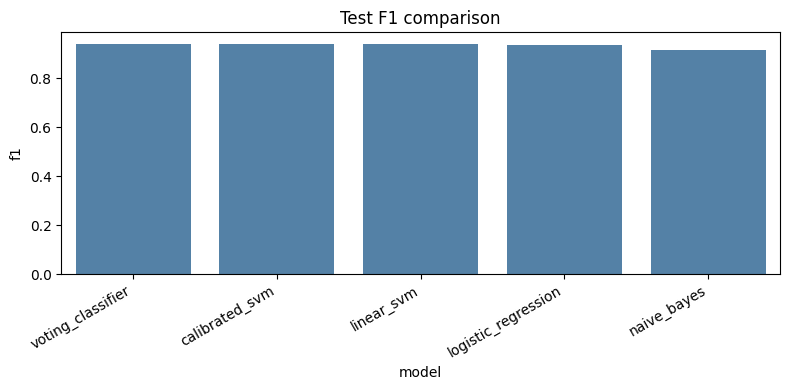

Saved figure: ../results/figures/test_f1_comparison.png


In [4]:
best_model_name = results_df.loc[0, "model"]
print("Best test model:", best_model_name)
print("Best test F1:", results_df.loc[0, "f1"])

plt.figure(figsize=(8, 4))
sns.barplot(data=results_df, x="model", y="f1", color="steelblue")
plt.xticks(rotation=30, ha="right")
plt.title("Test F1 comparison")
plt.tight_layout()
summary_path = figures_dir / "test_f1_comparison.png"
plt.savefig(summary_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved figure:", summary_path)